- To download this notebook, click the download icon in the toolbar above and select the .ipynb format.  
- For any questions or comments, please open an issue on the [c4dynamics issues page](https://github.com/C4dynamics/C4dynamics/issues).  

# Vehicle Steering Control Using MPC

The notebook implements a Model Predictive Controller (MPC) for vehicle steering. Using a simplified model to track a straight reference line, it solves a constrained finite-horizon quadratic program at each time step with `CVXPY`, while simulating the closed-loop vehicle dynamics using [c4dynamics](https://github.com/c4dynamics/c4dynamics).


## System Model

We consider a simplified kinematic model of a vehicle with 2 states `[ψ ; y]` `[1]`. See [Appendix for the linearization process](#Appendix).

$
\dot{\psi}(t) = \delta(t)
$

$
\dot{y}(t) = V \psi(t)
$

where:  
- `y` = lateral position [m]  
- `ψ` = heading angle [rad]  
- `V` = vehicle velocity [m/s]  
- `δ` = steering input [rad/s]

### 1. Control Objective
In this case, the primary goal is to follow a straight line at a constant velocity. The steering input `δ` is used to regulate the lateral position `ψ` and the heading angle `y`. For straight-line tracking, the desired lateral position and heading angle are both zero.
In this example, we assume ideal measurements (i.e., zero noise) and focus mainly on the MPC logic. In practical applications, various sensors (e.g., IMU, GPS, wheel encoders) and/or a Kalman filter would be used to measure or estimate the lateral position and heading angle.

### 2. Setup and Simulation Parameters

- Import required packages

In [184]:
import numpy as np
import cvxpy as cp
import c4dynamics as c4d
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

- Define vehicle speed, initial states, simulation step, and duration.

In [185]:
V = 22.3  # vehicle speed [m/s]

- Define initial states

In [186]:
psi0 = 0  # heading angle [rad]
y0 = 1    # lateral position [m]

- Define simulation step and duration

In [187]:
dt = 0.2   # time step [s]
t_end = 8  # simulation end time [s]

### 3.Vehicle Model Function

In [188]:
def vehicle_model(t, x, delta, V=V):
    psi, y = x
    return [delta, V * psi]

### 4. Initialize Vehicle State

Use `c4dynamics.state` to store vehicle states over time.


In [189]:
vehicle = c4d.state(psi=psi0, y=y0)
vehicle.delta = 0

## Model Predictive Controller (MPC)
The vehicle steering is controlled using a Model Predictive Controller. A MPC algorith is composed by 3 core elements `[2]`:

1. Prediction Model: A mathematical representation of the system (typically discrete-time) used to predict future system behavior over a defined prediction horizon `N`. It enables the controller to anticipate how current actions affect future states.
2. Cost Function: A scalar function that quantifies desired performance, typically penalizing tracking error and control effort. The MPC algorithm minimizes this function subject to constraints.
3. Control Law: Unlike traditional controllers with fixed gain formulas (e.g., PID), MPC computes the control law by solving a constrained optimization problem in real-time. The solver generates an optimal sequence of future control inputs, but only the first input is applied to the plant. This receding-horizon process repeats at each time step.

MPC is suitable for vehicle steering because it simultaneously addresses constraints, prediction, and optimization within a single control problem. Steering rate limits and actuator bounds can be enforced explicitly as constraints, ensuring physically feasible control actions. Unlike PID controllers, which react only to tracking errors, MPC optimizes a cost function over the prediction horizon, preventing the vehicle from entering unrecoverable states. This yields to smoother control actions and improved tracking performance, especially in constrained or highly dynamic scenarios.

For this case, the MPC computes the optimal steering input `δ` over a finite prediction horizon to regulate both the lateral position `y` and heading angle `ψ` of the vehicle.

### 1. MPC parameters

- **N**: prediction horizon   
- **Q**: state weighting   
- **R**: input weighting   

In [190]:
N = 20  # prediction horizon
Q = np.diag([150.0, 1.0])   # weight on [psi, y]
R = np.array([[1]])    # weight on delta

Steering Input Constraint:

To ensure the simulation reflects real-world physics, we apply a hard constraint on the steering rate:$$|\delta| \le 1^\circ/\text{s}$$

This constraint represents the actuator limitation (specifically the steering rate limit). In a real vehicle, the steering actuation cannot change the wheel angle instantaneously. Limiting the rate of change prevents the controller from requesting commands beyond the actuator capabilities.

- **u_max**: maximum steering input 

In [191]:
u_max = 0.017             # max steering rate [rad/s]

### 2. Prediction Model

 In a continuous system, motion is described by differential equations ($dx/dt$). The continuous-time kinematic model is:

$
\dot{\psi}(t) = \delta(t), \quad \dot{y}(t) = V \psi(t)
$

Computers and optimization solvers can't process a continuous "flow" of time. They require individual snapshots to do the math (discretization). Therefore, we break the motion into fixed time steps `dt`. This allows to predict the next state $x_{k+1}$ based on the current state $x_k$ and the control inputs $u_k$. The discrete model can be expressed as: $x_{k+1} = Ax_k + Bu_k$ `[3]`. For this example the timestep is `dt = 0.1 s`:

$
\psi_{k+1} = \psi_k + \delta_k \ dt
$

$
y_{k+1} = y_k + V \psi_k \ dt + 0.5 V \ dt^2 \ \delta_k
$

This linear approximation allows the MPC to "look ahead" into the future for a set number of steps (the horizon) to see where the car will end up before it actually moves.

In [192]:
A_d = np.array([
    [1.0, 0.0],
    [V * dt, 1.0]
])

B_d = np.array([
    [dt],
    [0.5 * V * dt**2]
])

### 3. Cost function

- Prediction horizon: `N` steps  
- Quadratic cost function:

$
J = \sum_{k=0}^{N-1} \left( x_k^\top Q x_k + u_k^\top R u_k \right) + x_N^\top Q x_N
$

- Steering constraints: $|\delta| \le 0.2 \text{ rad/s}$

### 4. Control law

The `solve_mpc(current_x)` function acts as the vehicle's "brain." It looks at the current position and calculates the best sequence of steering moves to stay on track without going beyond physical limits (like max steering angle). It uses `CVXPY`, a mathematical toolkit, to turn these goals and constraints into an optimization problem that can be solved instantly to find the most efficient path.

In [193]:
def solve_mpc(current_x):
    x = cp.Variable((2, N + 1))
    u = cp.Variable((1, N))
    cost = 0
    constraints = [x[:, 0] == current_x]

    for k in range(N):
        cost += cp.quad_form(x[:, k], Q) + cp.quad_form(u[:, k], R)
        constraints += [
            x[:, k+1] == A_d @ x[:, k] + B_d @ u[:, k],
            cp.abs(u[:, k]) <= u_max
        ]

    cost += cp.quad_form(x[:, N], Q)
    cp.Problem(cp.Minimize(cost), constraints).solve(solver=cp.OSQP)

    return u.value[0, 0]

## Simulation

The simulation workflow is illustrated below:

<div style='text-align: center;'>
  <img src='MPC_diagram.png' alt='alt text'>
</div>

At each time step:  

1. Measure current state and solve MPC for optimal steering input  
2. Apply the input and propagate the vehicle dynamics using `solve_ivp`  
3. Update and store the states

In [194]:
for ti in np.arange(0, t_end, dt):
    if ti >= 2 * dt:
        vehicle.delta = solve_mpc(vehicle.X)
    else:
        vehicle.delta = 0  # no steering input
    vehicle.storeparams('delta', t=ti)
    sol = solve_ivp(vehicle_model, [ti, ti + dt], vehicle.X, args=(vehicle.delta,))
    vehicle.X = sol.y[:, -1]
    vehicle.store(ti)

## Results

- Lateral position `y`: moves from the initial offset toward zero.  
- Heading angle `ψ`: adjusts transiently to correct lateral error.  
- Steering input `δ`: applies a bounded corrective action and settles near zero once stabilized.

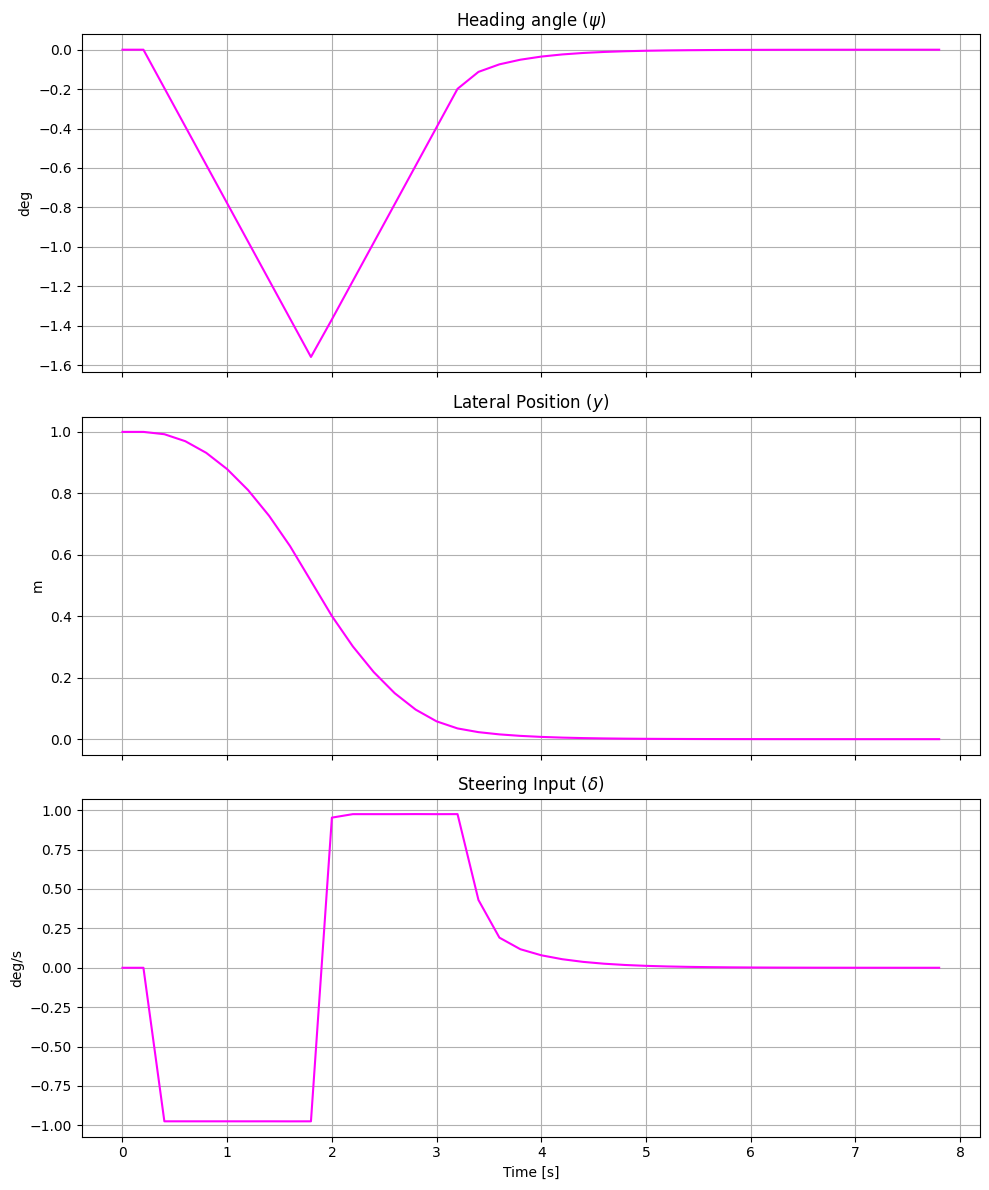

In [195]:
# Create a figure with 3 subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1. Heading Angle (psi) in degrees
axs[0].plot(*vehicle.data('psi', scale=c4d.r2d), color='magenta', linewidth=1.5)
axs[0].set_ylabel('deg')
axs[0].set_title('Heading angle ($\\psi$)')
axs[0].grid(True)

# 2. Lateral Position (y) in meters
axs[1].plot(*vehicle.data('y'), color='magenta', linewidth=1.5)
axs[1].set_ylabel('m')
axs[1].set_title('Lateral Position ($y$)')
axs[1].grid(True)

# 3. Steering Input (delta) in degrees
axs[2].plot(*vehicle.data('delta', scale=c4d.r2d), color='magenta', linewidth=1.5)
axs[2].set_ylabel('deg/s')
axs[2].set_xlabel('Time [s]')
axs[2].set_title('Steering Input ($\\delta$)')
axs[2].grid(True)

plt.tight_layout()
plt.show()

From the simulation results, it can be observed that the vehicle successfully tracks the desired path (straight line) after starting with an initial offset of 1 meter. The lateral error decreases to zero over time. The steering input remains smooth and bounded without aggressive oscillations.

These results highlight key MPC characteristics. The controller predicts future vehicle states and optimizes control actions accordingly. Constraints on steering input are enforced through the optimization problem. The receding horizon strategy ensures robustness to small modeling errors and disturbances by continuously updating the solution based on the current state.

## Conclusions

This guide demonstrates the implementation of an MPC for vehicle steering using a kinematic model. The controller was able to track a straight reference path while producing smooth and bounded steering commands.

By using a mathematical model of the vehicle, the controller predicts future states over a horizon and computes a sequence of steering actions that keep the vehicle on track in an optimal way. Unlike simpler controllers, MPC accounts for physical limitations, such as maximum steering input, ensuring that all control actions remain feasible. By balancing multiple goals, like following a straight path while minimizing passenger discomfort (jerk), it achieves a sophisticated, human-like driving behavior.

Possible extensions of this work include:

- Using a more detailed vehicle model that captures tire forces, lateral slip, and dynamic effects
- Extending the controller to handle steering and speed control simultaneously
- Implementing a nonlinear MPC formulation for more complex scenarions such as higher speeds or more aggressive maneuvers
- Replacing the analytical model with a neural network to develop a Neural MPC controller

## References

[1] D. Gorinevsky Lecture notes: Stanford EE392M, Lecture 14: Model Predictive Control. [Online]. Available: https://web.stanford.edu/class/archive/ee/ee392m/ee392m.1056/Lecture14_MPC.pdf

[2] E. F. Camacho and C. Bordons, “Model predictive control, ” in Advanced Textbooks in Control and Signal Processing. London, U.K., Springer, 2007.

[3] J. B. Rawlings, D. Q. Mayne and M. M. Diehl, “Model Predictive Control: Theory, Computation, and Design, ” 2ed. Santa Barbara, U.S., Nob Hill, 2019.

# Appendix 
## Complete Linearization of a Planar Kinematic Model

In [System Model](#system-model) we presented the final form of the linear simplified representation of the system.  


The steps for a formal linearization:  

1. Write the nonlinear model
2. Choose an operating point
3. Define perturbation variables 
4. Compute Jacobians
5. Expand first-order Taylor series
6. Form the linear state-space model 
7. Validate the linearization

In this appendix we go step by step to linearize the planar kinematic of a vehicle about a straight-line reference trajectory. 

## 1. Nonlinear Continuous-Time Model

We consider a point mass moving in the plane with constant speed ($V$) and heading angle ($\psi$).  
The control input is the heading rate.
To avoid confusion with the approximation operator $\delta$, we use $u$ as the control input along the appendix. 

Precise nonlinear equations: 

$$
\begin{aligned}
\dot{x} = V \cdot \cos\psi \\
\dot{y} = V \cdot \sin\psi \\
\dot{\psi} = u
\end{aligned}
$$

where:  
- $x$: longitudinal position [m]
- $y$: lateral position [m]  
- $V$: vehicle velocity [m/s]  
- $ψ$: heading angle [rad]  
- $u$: steering input [rad/s]

State vector:  

$$
X = \begin{bmatrix} 
x & y & \psi 
\end{bmatrix}^T
$$


To linearize the system we have to define a reference trajectory, or operating point, about which the system is approximated. 

---


## 2. Reference Trajectory (Operating Point)

We linearize the system about a **straight-line motion** with constant heading ($\psi_r$) and zero control input.


$$
\begin{aligned}
\psi_r &= \text{const.} \\
u_r &= 0
\end{aligned}
$$

The corresponding reference trajectory $X_r$ is:


$$
\begin{aligned}
x_r(t) = V \cdot \cos\psi_r \cdot t \\
y_r(t) = V \cdot \sin\psi_r \cdot t \\
\psi_r(t) = \psi_r
\end{aligned}
$$


### Time Derivative of the Reference Trajectory

Differentiation of the reference trajectory gives: 
$$
\dot{X}_r =
\begin{bmatrix}
V \cdot \cos\psi_r \\
V \cdot \sin\psi_r \\
0
\end{bmatrix}
$$



### Consistency Check

Substituting $(\mathbf{X}_r, u_r)$ into the nonlinear model gives:


$$
\begin{aligned}
\dot{x} &= V \cdot \cos\psi_r \\
\dot{y} &= V \cdot \sin\psi_r \\
\dot{\psi} &= 0
\end{aligned}
$$

which matches $\dot{X}_r$.  
Thus, the reference is dynamically consistent.


The complete trajectory is therefore a construction of a straight line and a deviations part. 

Deviations from this reference trajectory can now be approximated by the linear parts of a Taylor series. 

---


## 3. Perturbation Variables

Define deviations $\delta{X}, \delta{u}$ from the reference trajectory:

$$
\begin{aligned}
\delta{X} = X - X_r  \\
\delta{u} = u - u_r  
\end{aligned}
$$

With time derivative:

$$
\dot{X} = \dot{X}_r + \delta \dot{X}
$$

These nonlinear deviations can be approximated by the first-order terms with in the Taylor expansion with respect to the state and the input deviations. 


![linearization](linearization.png)
---


## 4. First-Order Taylor Expansion

Let: 
$$
\dot{X} = f(X, u)
$$

A first-order Taylor expansion about $(X_r, u_r)$ yields (higher order terms are neglected): 

$$
\begin{aligned}

\dot{X} = \dot{X}_r + \delta \dot{X} \approx f(X_r, u_r)

+ \left.\frac{\partial f}{\partial X}\right|_{r} \cdot \Delta X
+ \left.\frac{\partial f}{\partial u}\right|_{r} \cdot \Delta u

\end{aligned}
$$

Since
$$
\dot{X}_r = f(X_r, u_r)
$$

the perturbation dynamics are

$$
\Delta \dot{X} = A \cdot \Delta X + B \cdot \Delta u
$$

Where:

- $\Delta \dot{X} \approx \delta \dot{X}$
- $A = \left.\frac{\partial f}{\partial X}\right|_{r}$  
- $B = \left.\frac{\partial f}{\partial u}\right|_{r}$

---


## 5. Jacobian Computation

$A$ and $B$ are given by the Jacobians, i.e., the partial derivatives of $f$ with respect to the state $X$ and with respect to the input $u$. 

### Jacobian with Respect to the State

$$
A = \left.\frac{\partial f}{\partial X}\right|_{X_r, u_r}
$$

Partial derivatives:

$$
\begin{aligned}

\frac{\partial \dot{x}} {\partial x}      = 0, &
\frac{\partial \dot{x}} {\partial y}      = 0, &
\frac{\partial \dot{x}} {\partial \psi} = -V \cdot \sin\psi_r \\

\frac{\partial \dot{y}} {\partial x}      = 0, &
\frac{\partial \dot{y}} {\partial y}      = 0, &
\frac{\partial \dot{y}} {\partial \psi} = V \cdot \cos\psi_r \\

\frac{\partial \dot{\psi}} {\partial x} = 0, &
\frac{\partial \dot{\psi}} {\partial y} = 0, &
\frac{\partial \dot{\psi}} {\partial \psi} = 0

\end{aligned}
$$

Thus

$$
A =
\begin{bmatrix}
0 & 0 & -V \cdot \sin\psi_r \\
0 & 0 &  V \cdot \cos\psi_r \\
0 & 0 & 0
\end{bmatrix}
$$



### Jacobian with Respect to the Input

$$
B = \left.\frac{\partial f}{\partial u}\right|_{X_r, u_r}
= \begin{bmatrix}
0 \\
0 \\
1
\end{bmatrix}
$$

---


## 6. Linearized Continuous-Time System

Substitution of the coefficients of $A$ and $B$ into the equation representation of the system: 

$$
\begin{aligned}
\Delta \dot{x} = -V \cdot \sin\psi_r \cdot \Delta \psi \\
\Delta \dot{y} =  V \cdot \cos\psi_r \cdot \Delta \psi \\
\Delta \dot{\psi} = \Delta u
\end{aligned}
$$

Recall that $\delta{X}$ represents the true nonlinear deviation, while $\Delta{X}$ denotes its first-order approximation used by the linear model.  
The physical interpretation of the coefficients in the linearized equations is as follows:  
- At first order, position deviations are caused only by heading perturbations. Velocity components aligned with the reference trajectory affect position only through higher-order terms.
- The tangent component (along the reference velocity) contributes only at second order, so it does not appear in the linearized $(\delta x, \delta y)$ equations.  
- The term $-V \cdot \sin\psi_r$ is the $x$-component of the normal component of the velocity deviation.  
- The term $V \cdot \cos\psi_r$ is the $y$-component of the normal component of the velocity deviation.


Define:

$$
\begin{aligned}
V_x = -V \cdot \sin\psi_r \\
V_y =  V \cdot \cos\psi_r
\end{aligned}
$$

Then:

$$
\begin{aligned}
\Delta \dot{x} = V_x \cdot \Delta \psi \\
\Delta \dot{y} = V_y \cdot \Delta \psi \\
\Delta \dot{\psi} = \Delta u
\end{aligned}
$$

This is the final linearized form of the a planar kinematic of a vehicle about a straight-line reference trajectory.  

### Notation Modification 

From this point onward, we redefine the perturbation variables $(\Delta{x} \rightarrow x,\Delta{y} \rightarrow y,\Delta{\psi} \rightarrow \psi)$ as the system state for notational simplicity.
Or simply: 

$$
\begin{aligned}
\dot{x} = V_x \cdot \psi \\
\dot{y} = V_y \cdot \psi \\
\dot{\psi} = u
\end{aligned}
$$


---


## 7. Zero-Heading Reference Simplification 

Now, let's assume the reference trajectory is parallel to the $x$ axis, i.e. $\psi_r = 0$.  

The linear model simplifies to:  

$$
\begin{aligned}
V_x = -V \cdot \sin 0 = 0 \\
V_y =  V \cdot \cos 0 = V  \\
\end{aligned}
$$

That is:

$$
\begin{aligned}
\dot{x} = 0 \\
\dot{y} = V \cdot \psi \\
\dot{\psi} = u
\end{aligned}
$$


Under this assumption the perturbation dynamics is as follows: 
- No motion in $x$ ($\dot{x} = 0$)
- The velocity in $y$ is simply the velocity angle ($\psi$) scaled by the velocity magnitude ($V$) 

Since the perturbation in $x$ is identically zero for a straight reference aligned with the $x$-axis, the $x$-state can be omitted from the perturbation dynamics without loss of information:

$$
\begin{aligned}
\dot{y} = V \cdot \psi \\
\dot{\psi} = u
\end{aligned}
$$

This simplified perturbation system is used by the MPC optimizer to minimize deviations from the reference trajectory.  
However, for simulation of the vehicle dynamics, the complete state must be reconstructed as:

$$
\begin{aligned}
X = X_r + \Delta{X}
\end{aligned}
$$

Where $X_r$ is the reference dynamics: 


$$
\begin{aligned}
x_r(t) = V \cdot t  \\
y_r(t) = 0          \\
\psi_r(t) = 0
\end{aligned}
$$


And $\Delta{X}$ is the solution of the linearized dynamics. 

--- 


## 8. Discrete-Time Linear Model

Let's discretize the reference model and linearized model using forward Euler discretization with time-step ($dt$):

$$ 
\Delta X_{k+1} = (I + A \cdot dt) \cdot \Delta X_k + B \cdot dt \cdot \Delta u_k = F \cdot \Delta X_k + G \cdot \Delta u_k = 
$$


### Discrete-Time Linearized Model 


$$
F =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 &  V \cdot dt \\
0 & 0 & 1
\end{bmatrix},
\quad
G =
\begin{bmatrix}
0 \\
0 \\
dt
\end{bmatrix}
$$

For input $u$. 

### Discrete-Time Reference Model


$$
F_r =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix},
\quad
G_r =
\begin{bmatrix}
V \cdot dt \\
0 \\
0
\end{bmatrix}
$$

Where the reference input corresponds to constant forward velocity. 


---

## 9. Example 

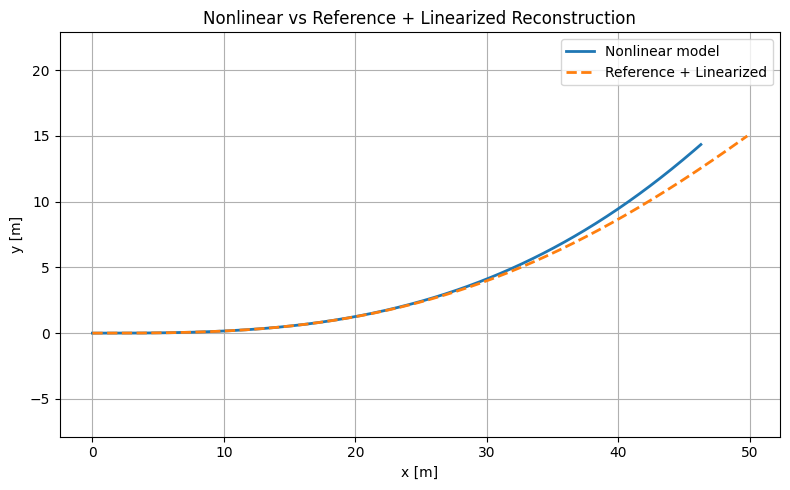

In [196]:
import numpy as np
import matplotlib.pyplot as plt
import c4dynamics as c4d

# -----------------------------
# Parameters
# -----------------------------
V = 10.0          # [m/s]
dt = 0.01         # [s]
T  = 5.0          # [s]
N  = int(T / dt)

# Small steering input (heading rate)
def u(t):
  return 0.2 * np.sin(0.5 * t)

# Nonlinear system 
nln_sys = c4d.state(x = 0.0, y = 0.0, psi = 0.0)

# Reference trajectory 
ref_sys = c4d.state(x = 0.0, y = 0.0, psi = 0.0)

# Linearized model
lin_sys = c4d.state(y = 0.0, psi = 0.0)

for k in range(N - 1):
  t = k * dt
  nln_sys.store(t)
  ref_sys.store(t)
  lin_sys.store(t)

  # nonlinear system
  nln_sys.X += [V * np.cos(nln_sys.psi) * dt,
                V * np.sin(nln_sys.psi) * dt,
                u(t) * dt] 

  # reference system
  ref_sys.X += [V * dt, 0, 0]

  # linear system 
  lin_sys.X += [V * lin_sys.psi * dt,
                u(t) * dt]


# Reconstruct full state
x_rec = ref_sys.data('x')[1]
y_rec = ref_sys.data('y')[1] + lin_sys.data('y')[1]

# Plot
plt.figure(figsize = (8, 5))
plt.plot(nln_sys.data('x')[1], nln_sys.data('y')[1], label = "Nonlinear model", linewidth = 2)
plt.plot(x_rec, y_rec, "--", label = "Reference + Linearized", linewidth=2)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Nonlinear vs Reference + Linearized Reconstruction")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()
